In [8]:
# This cell imports all required libraries

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_India"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers)
response

<Response [200]>

In [27]:
soup=BeautifulSoup(response.text,"html.parser")

In [44]:
table=soup.find_all("table", class_="wikitable sortable")[0]
table

<table class="wikitable sortable" style="text-align:right;">
<tbody><tr>
<th align="center">Rank
</th>
<th align="center">Forbes<br/> 2000 rank
</th>
<th align="center">Name
</th>
<th align="center">Headquarters
</th>
<th align="center">Revenue<br/>(billions US$)
</th>
<th align="center">Profit<br/>(billions US$)
</th>
<th align="center">Assets<br/>(billions US$)
</th>
<th align="center">Value<br/>(billions US$)
</th>
<th align="center">Industry
</th></tr>
<tr>
<td>1
</td>
<td>49
</td>
<td align="left"><a class="mw-redirect" href="/wiki/Reliance_Industries_Limited" title="Reliance Industries Limited">Reliance Industries Limited</a>
</td>
<td align="left">Mumbai
</td>
<td>108.8
</td>
<td>8.4
</td>
<td>210.5
</td>
<td>233.1
</td>
<td align="left"><a href="/wiki/Conglomerate_(company)" title="Conglomerate (company)">Conglomerate</a>
</td></tr>
<tr>
<td>2
</td>
<td>55
</td>
<td align="left"><a href="/wiki/State_Bank_of_India" title="State Bank of India">State Bank of India</a>
</td>
<td al

In [45]:
world_title=table.find_all('th')
world_title

[<th align="center">Rank
 </th>,
 <th align="center">Forbes<br/> 2000 rank
 </th>,
 <th align="center">Name
 </th>,
 <th align="center">Headquarters
 </th>,
 <th align="center">Revenue<br/>(billions US$)
 </th>,
 <th align="center">Profit<br/>(billions US$)
 </th>,
 <th align="center">Assets<br/>(billions US$)
 </th>,
 <th align="center">Value<br/>(billions US$)
 </th>,
 <th align="center">Industry
 </th>]

In [46]:
headings=[]
for title in world_title:
    headings.append(title.text.strip())
headings 

['Rank',
 'Forbes 2000 rank',
 'Name',
 'Headquarters',
 'Revenue(billions US$)',
 'Profit(billions US$)',
 'Assets(billions US$)',
 'Value(billions US$)',
 'Industry']

## **Creating a DataFrame**

In [64]:
df=pd.DataFrame(columns=headings)
df
len(df)

0

In [50]:
column_data=table.find_all('tr')
column_data

[<tr>
 <th align="center">Rank
 </th>
 <th align="center">Forbes<br/> 2000 rank
 </th>
 <th align="center">Name
 </th>
 <th align="center">Headquarters
 </th>
 <th align="center">Revenue<br/>(billions US$)
 </th>
 <th align="center">Profit<br/>(billions US$)
 </th>
 <th align="center">Assets<br/>(billions US$)
 </th>
 <th align="center">Value<br/>(billions US$)
 </th>
 <th align="center">Industry
 </th></tr>,
 <tr>
 <td>1
 </td>
 <td>49
 </td>
 <td align="left"><a class="mw-redirect" href="/wiki/Reliance_Industries_Limited" title="Reliance Industries Limited">Reliance Industries Limited</a>
 </td>
 <td align="left">Mumbai
 </td>
 <td>108.8
 </td>
 <td>8.4
 </td>
 <td>210.5
 </td>
 <td>233.1
 </td>
 <td align="left"><a href="/wiki/Conglomerate_(company)" title="Conglomerate (company)">Conglomerate</a>
 </td></tr>,
 <tr>
 <td>2
 </td>
 <td>55
 </td>
 <td align="left"><a href="/wiki/State_Bank_of_India" title="State Bank of India">State Bank of India</a>
 </td>
 <td align="left">Mumbai
 <

In [70]:
individual_row=[]
for row in column_data[1:]:
    individual_row=[]
    row_data=row.find_all('td')
    for data in row_data:
        individual_row.append(data.text.strip())

    #print(individual_row)
    length=len(df)
    #length
    df.loc[length]=individual_row
         

In [71]:
df

,Rank,Forbes 2000 rank,Name,Headquarters,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry
0,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate
1,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate
2,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate
3,2,55,State Bank of India,Mumbai,71.8,8.1,807.4,87.6,Banking
4,3,65,HDFC Bank,Mumbai,49.3,7.7,483.2,133.6,Banking
...,...,...,...,...,...,...,...,...,...
68,65,1895,Dr. Reddy's Laboratories,Hyderabad,3.4,0.7,4.6,11.6,Pharmaceuticals
69,66,1908,Varun Beverages,Gurgaon,2.0,0.3,1.8,23.6,Beverages
70,67,1949,CIFCL,Chennai,2.3,0.4,18.8,13.0,Financials
71,68,1957,NMDC,Hyderabad,2.5,0.8,3.9,9.7,Mining


## **visualization**

### **1. Top 10 Companies by Revenue (Bar Chart)**

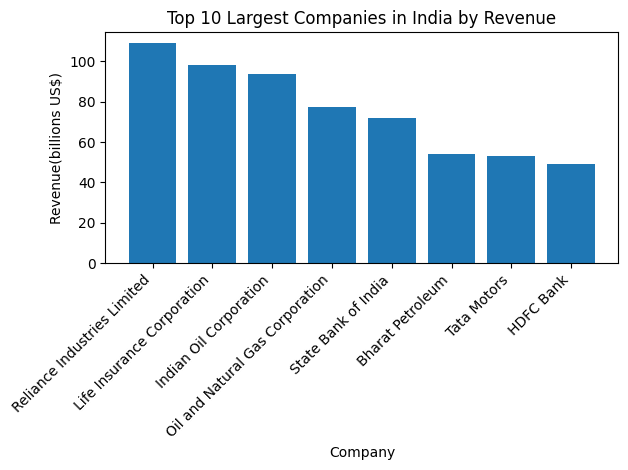

In [74]:
# Clean numeric columns
df['Revenue(billions US$)'] = df['Revenue(billions US$)'].str.replace(',', '').astype(float)

# Sort and select top 10
top10 = df.sort_values(by='Revenue(billions US$)', ascending=False).head(10)

# Plot
plt.figure()
plt.bar(top10['Name'], top10['Revenue(billions US$)'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Company")
plt.ylabel("Revenue(billions US$)")
plt.title("Top 10 Largest Companies in India by Revenue")
plt.tight_layout()
plt.show()

### **2. Industry Distribution (Bar Chart)**

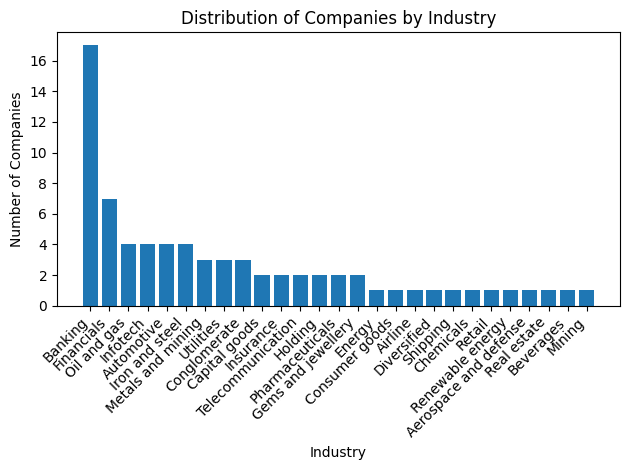

In [76]:
industry_counts = df['Industry'].value_counts()

plt.figure()
plt.bar(industry_counts.index, industry_counts.values)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Industry")
plt.ylabel("Number of Companies")
plt.title("Distribution of Companies by Industry")

plt.tight_layout()
plt.show()

### **3. Histogram of Revenue Distribution**

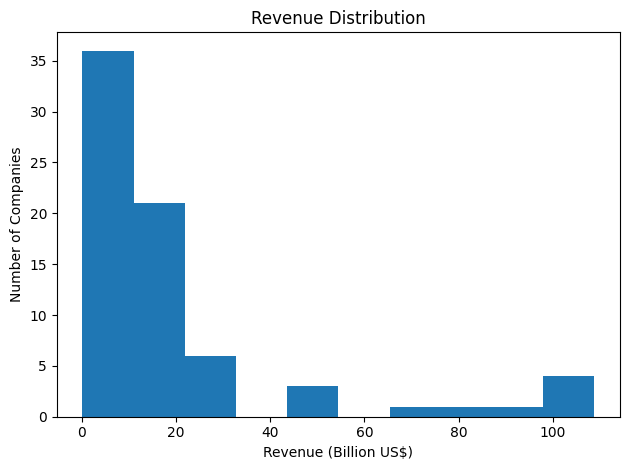

In [84]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure()

plt.hist(
    pd.to_numeric(
        df['Revenue(billions US$)']
        .astype(str)                 # convert to string
        .str.replace(',', '')        # remove commas
        .str.replace('−', '-'),      # fix unicode minus
        errors='coerce'              # invalid → NaN
    ).dropna(),
    bins=10
)

plt.xlabel("Revenue (Billion US$)")
plt.ylabel("Number of Companies")
plt.title("Revenue Distribution")

plt.tight_layout()
plt.show()

### **4. Box Plot of Profit**

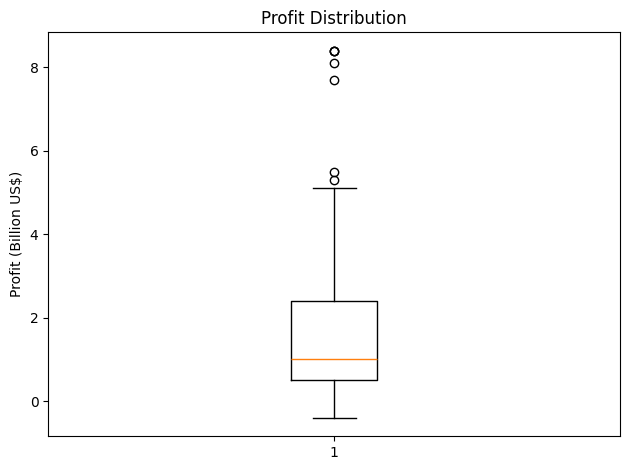

In [85]:
plt.figure()

plt.boxplot(
    pd.to_numeric(
        df['Profit(billions US$)']
        .astype(str)                 # convert to string
        .str.replace(',', '')
        .str.replace('−', '-'),
        errors='coerce'
    ).dropna()
)

plt.ylabel("Profit (Billion US$)")
plt.title("Profit Distribution")

plt.tight_layout()
plt.show()